# Kiểm chứng PPS core bằng hệ Rössler

Notebook kiểm tra vùng bán kính nhiễu tối ưu, khả năng bảo toàn hình học thô và surrogate test phân biệt chaos với period-6 có nhiễu. Toàn bộ thao tác sinh PPS dùng core trong `phase1/src/surrogates/pps.py`.

## Task 0 - Thiết lập môi trường và tham số

Cố định seed để kết quả có thể tái lập. Có thể tăng `RHO_TRIALS` khi cần đường cong ổn định hơn.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree


def find_project_root():
    """Locate the repository root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        pps_path = (
            candidate / "phase1" / "src" / "surrogates" / "pps.py"
        )
        if pps_path.exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy phase1/src/surrogates/pps.py.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "phase1"))

from src.surrogates.pps import (
    count_matching_segments,
    embed_phase_space,
    generate_pps_indices,
    generate_pps_signal,
)

N_SAMPLES = 5_000
SAMPLE_STEP = 0.2
INTEGRATION_STEP = 0.01
TRANSIENT_TIME = 200.0
NOISE_SIGMA = 0.05
EMBEDDING_DIMENSION = 3
DELAY = 8
RHO_CANDIDATES = np.logspace(-10, 0, 41)
RHO_TRIALS = 3
SEGMENT_LENGTHS = (2, 3, 4, 5)
N_SURROGATES = 30
ALPHA = 0.05

DATASET_CONFIGS = {
    "Chaos": {"a": 0.398, "seed": 20_261},
    "Period-6": {"a": 0.3909, "seed": 20_262},
}

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## Task 0.5 - Kiểm tra định nghĩa Cn của core

Các test bắt buộc xác nhận `count_matching_segments` đếm maximal runs có độ dài đúng bằng `n`, không đếm các cửa sổ chồng lấn.

In [2]:
segment_test_cases = [
    ([10, 11], {2: 1, 3: 0}),
    ([10, 11, 12], {2: 0, 3: 1}),
    ([10, 11, 12, 13, 14], {2: 0, 3: 0, 4: 0, 5: 1}),
    ([10, 11, 30, 31, 50, 51, 52, 90, 91], {2: 3, 3: 1}),
    (list(range(10)), {2: 0, 3: 0, 4: 0, 10: 1}),
    ([10, 50, 100, 200, 400], {2: 0, 3: 0, 4: 0}),
]

for indices, expected_counts in segment_test_cases:
    for segment_length, expected_count in expected_counts.items():
        actual_count = count_matching_segments(
            indices, segment_length
        )
        assert actual_count == expected_count, (
            indices,
            segment_length,
            expected_count,
            actual_count,
        )

print(f"Passed {len(segment_test_cases)} maximal-run test cases.")

Passed 6 maximal-run test cases.


## Task 1 - Mô phỏng hai hệ Rössler có nhiễu động lực

Nhiễu Gaussian độc lập được đưa vào cả ba phương trình theo dạng SDE. Euler–Maruyama dùng bước tích phân 0.01; phần quá độ được loại trước khi lấy 5.000 mẫu của thành phần `x` với bước 0.2.

In [3]:
def rossler_drift(state, a):
    """Return the deterministic Rössler drift."""
    x, y, z = state
    return np.array((-(y + z), x + a * y, 2.0 + z * (x - 4.0)))


def simulate_rossler(
    a,
    seed,
    n_samples=N_SAMPLES,
    sample_step=SAMPLE_STEP,
    integration_step=INTEGRATION_STEP,
    transient_time=TRANSIENT_TIME,
    noise_sigma=NOISE_SIGMA,
):
    """Simulate a noisy Rössler trajectory."""
    ratio = sample_step / integration_step
    steps_per_sample = int(round(ratio))
    if not np.isclose(ratio, steps_per_sample):
        raise ValueError("sample_step phải là bội của integration_step.")

    rng = np.random.default_rng(seed)
    burn_steps = int(round(transient_time / integration_step))
    total_steps = burn_steps + n_samples * steps_per_sample
    noise_scale = noise_sigma * np.sqrt(integration_step)
    trajectory = np.empty((n_samples, 3), dtype=float)
    state = np.array((1.0, 0.0, 0.0), dtype=float)
    sample_index = 0

    for step in range(total_steps):
        diffusion = noise_scale * rng.standard_normal(3)
        state += rossler_drift(state, a) * integration_step + diffusion
        if (
            step >= burn_steps
            and (step - burn_steps) % steps_per_sample == 0
        ):
            trajectory[sample_index] = state
            sample_index += 1

    return trajectory


datasets = {}
for name, config in DATASET_CONFIGS.items():
    trajectory = simulate_rossler(**config)
    datasets[name] = {
        "a": config["a"],
        "trajectory": trajectory,
        "signal": trajectory[:, 0],
    }

simulation_summary = pd.DataFrame(
    {
        name: {
            "a": data["a"],
            "n": len(data["signal"]),
            "mean_x": data["signal"].mean(),
            "std_x": data["signal"].std(),
            "min_x": data["signal"].min(),
            "max_x": data["signal"].max(),
        }
        for name, data in datasets.items()
    }
).T
simulation_summary

,a,n,mean_x,std_x,min_x,max_x
Chaos,0.3980,5000.0,0.420495,2.248236,-3.737277,5.653315
Period-6,0.3909,5000.0,0.413688,2.292858,-3.616264,5.447587


## Task 2 - Kiểm tra nhanh tín hiệu quan sát

Biểu đồ 1.000 mẫu đầu dùng để phát hiện hiện tượng phân kỳ, collapse hoặc sai bước lấy mẫu.

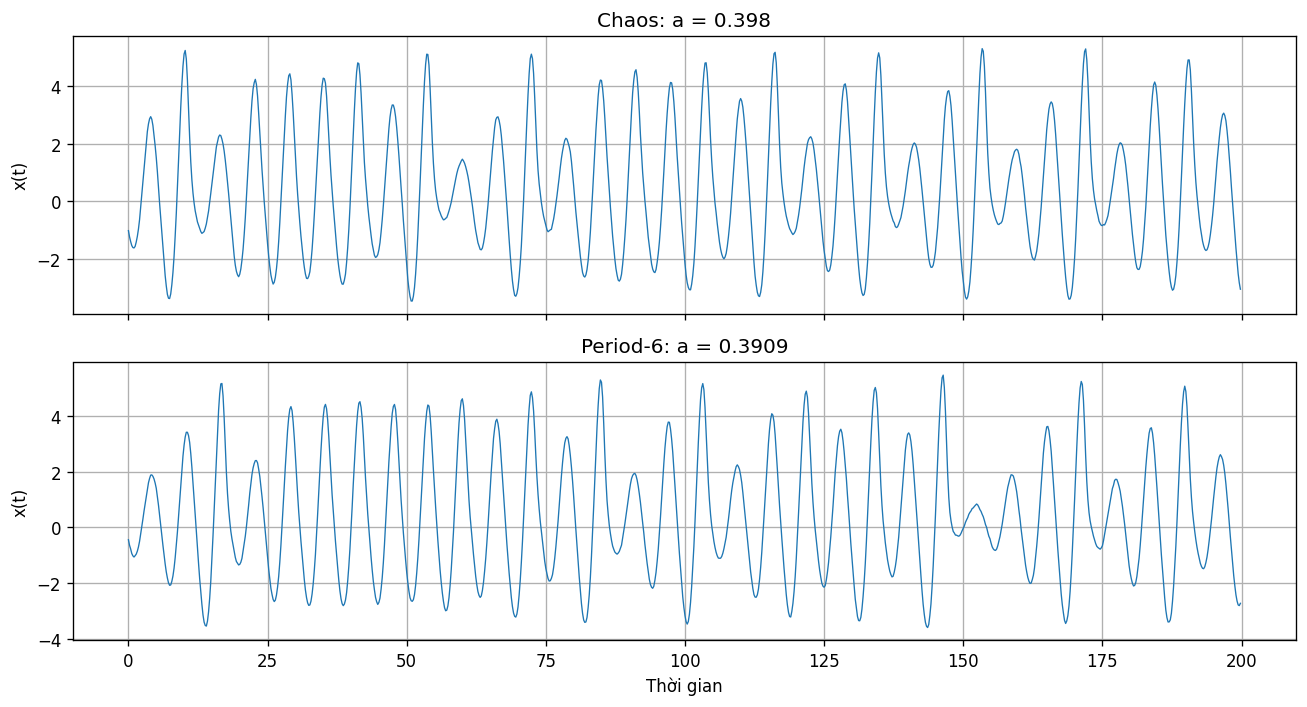

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
time = np.arange(1_000) * SAMPLE_STEP

for axis, (name, data) in zip(axes, datasets.items()):
    axis.plot(time, data["signal"][:1_000], linewidth=0.8)
    axis.set_title(f"{name}: a = {data['a']}")
    axis.set_ylabel("x(t)")

axes[-1].set_xlabel("Thời gian")
fig.tight_layout()
plt.show()

## Task 3 - Quét bán kính nhiễu và tính C2, C3, C4, C5

Mỗi trajectory chỉ số được sinh bởi `generate_pps_indices`. Giá trị `C_n` được tính trực tiếp bằng `count_matching_segments` của core và lấy trung bình trên các trial độc lập.

In [5]:
def sweep_rho(signal, rho_candidates, trials, seed):
    """Evaluate matching counts over a rho grid."""
    embedded = embed_phase_space(signal, DELAY, EMBEDDING_DIMENSION)
    counts = np.empty(
        (len(SEGMENT_LENGTHS), len(rho_candidates), trials),
        dtype=float,
    )
    seed_sequence = np.random.SeedSequence(seed)
    child_seeds = iter(
        seed_sequence.spawn(len(rho_candidates) * trials)
    )

    for rho_index, rho in enumerate(rho_candidates):
        for trial in range(trials):
            indices = generate_pps_indices(
                z=embedded,
                rho=rho,
                length=len(signal),
                rng=np.random.default_rng(next(child_seeds)),
            )
            for length_index, segment_length in enumerate(
                SEGMENT_LENGTHS
            ):
                counts[length_index, rho_index, trial] = (
                    count_matching_segments(indices, segment_length)
                )

    standard_deviation = (
        counts.std(axis=2, ddof=1)
        if trials > 1
        else np.zeros_like(counts[:, :, 0])
    )
    return {
        "mean": counts.mean(axis=2),
        "std": standard_deviation,
        "raw": counts,
    }


rho_results = {}
for dataset_index, (name, data) in enumerate(datasets.items()):
    rho_results[name] = sweep_rho(
        signal=data["signal"],
        rho_candidates=RHO_CANDIDATES,
        trials=RHO_TRIALS,
        seed=30_000 + dataset_index,
    )

## Task 4 - Vẽ Cn(r) và chọn r*

Theo đặc tả, `r*` là ứng viên làm cực đại đường `C2`. Vùng màu xanh là dải tham chiếu 0.002–0.006.

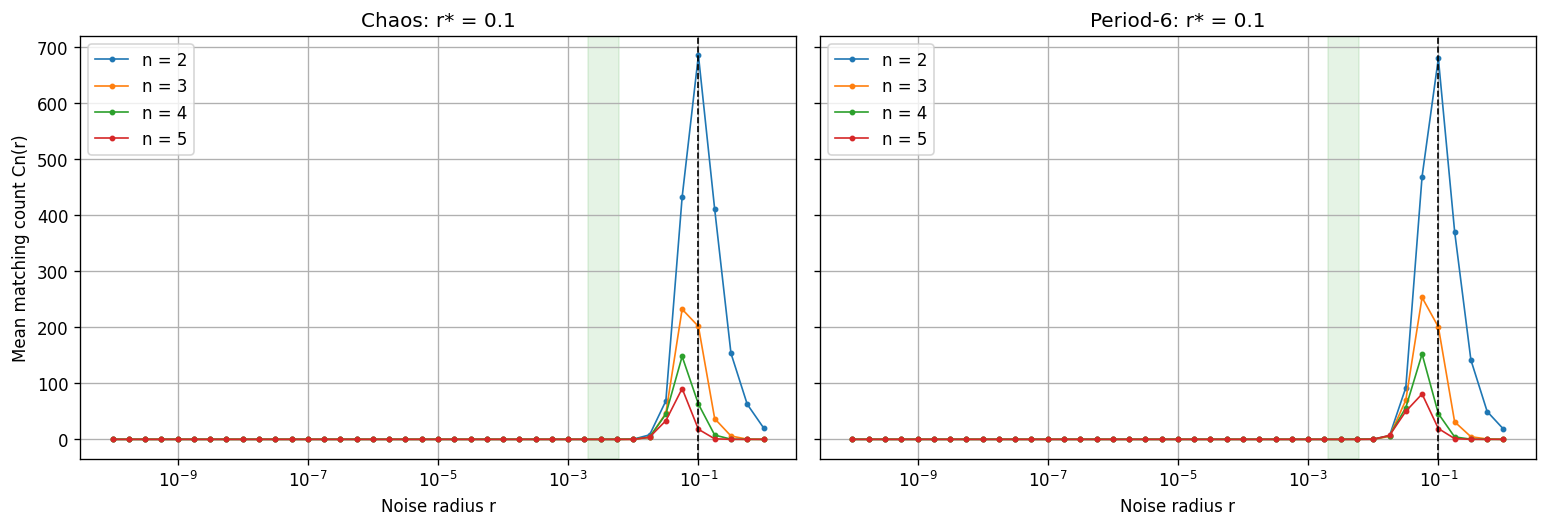

,optimal_rho,in_reference_range
Chaos,0.1,False
Period-6,0.1,False


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
optimal_rho = {}

for axis, (name, result) in zip(axes, rho_results.items()):
    for length_index, segment_length in enumerate(SEGMENT_LENGTHS):
        axis.semilogx(
            RHO_CANDIDATES,
            result["mean"][length_index],
            marker="o",
            markersize=2.5,
            linewidth=1.0,
            label=f"n = {segment_length}",
        )

    best_index = int(np.argmax(result["mean"][0]))
    best_rho = float(RHO_CANDIDATES[best_index])
    optimal_rho[name] = best_rho
    axis.axvline(
        best_rho, color="black", linestyle="--", linewidth=1.0
    )
    axis.axvspan(0.002, 0.006, color="tab:green", alpha=0.12)
    axis.set_title(f"{name}: r* = {best_rho:.3g}")
    axis.set_xlabel("Noise radius r")
    axis.legend()

axes[0].set_ylabel("Mean matching count Cn(r)")
fig.tight_layout()
plt.show()

rho_summary = pd.DataFrame.from_dict(
    optimal_rho, orient="index", columns=["optimal_rho"]
)
rho_summary["in_reference_range"] = rho_summary[
    "optimal_rho"
].between(0.002, 0.006)
rho_summary

## Task 5 - Sinh PPS tại r*

Mỗi surrogate có cùng độ dài tín hiệu gốc và dùng seed riêng.

In [7]:
for dataset_index, (name, data) in enumerate(datasets.items()):
    data["pps"] = generate_pps_signal(
        signal=data["signal"],
        tau=DELAY,
        m=EMBEDDING_DIMENSION,
        rho=optimal_rho[name],
        rng=np.random.default_rng(40_000 + dataset_index),
    )

pps_summary = pd.DataFrame(
    {
        name: {
            "original_n": len(data["signal"]),
            "pps_n": len(data["pps"]),
            "original_std": data["signal"].std(),
            "pps_std": data["pps"].std(),
        }
        for name, data in datasets.items()
    }
).T
pps_summary

,original_n,pps_n,original_std,pps_std
Chaos,5000.0,5000.0,2.248236,2.220258
Period-6,5000.0,5000.0,2.292858,2.311553


## Task 6 - So sánh hình học attractor và miền thời gian

Embedding của core được đảo cột để biểu diễn `(x_t, x_{t-tau}, x_{t-2tau})`. Khoảng cách láng giềng chuẩn hóa bổ sung kiểm tra định lượng cho hình học thô.

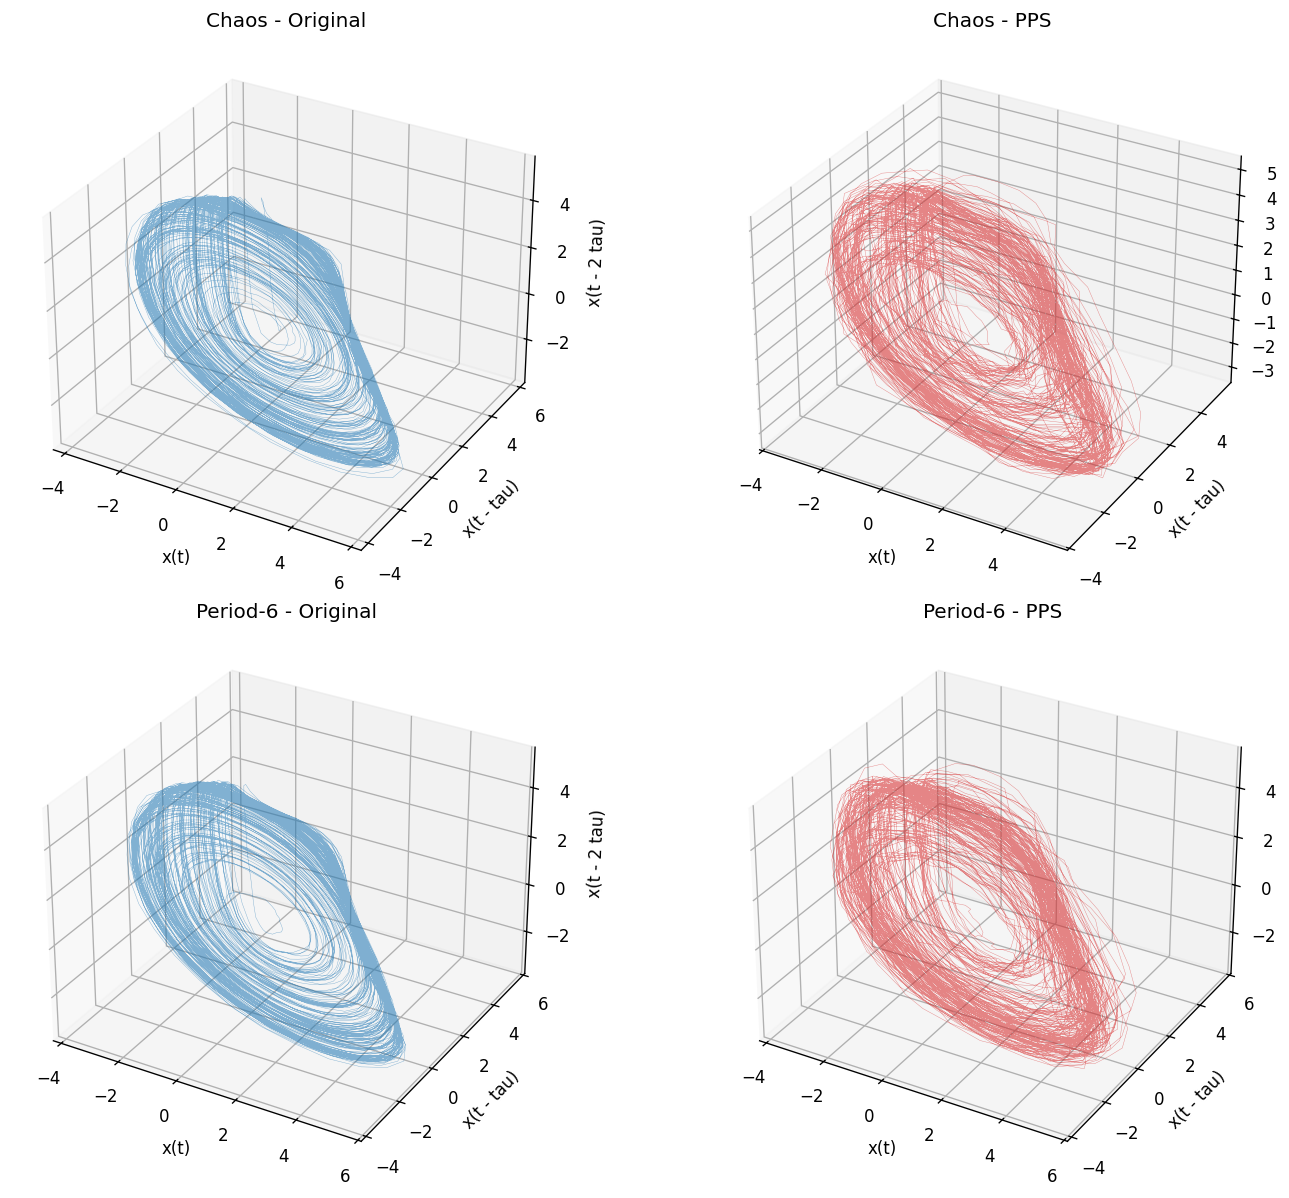

,normalized_geometry_error
Chaos,0.010369
Period-6,0.010716


In [8]:
def backward_embedding(signal):
    """Return backward-lag coordinates."""
    embedded = embed_phase_space(
        signal, DELAY, EMBEDDING_DIMENSION
    )
    return embedded[:, ::-1]


def normalized_geometry_error(original, surrogate):
    """Measure distance to the original attractor."""
    original_z = backward_embedding(original)
    surrogate_z = backward_embedding(surrogate)
    distances, _ = cKDTree(original_z).query(surrogate_z, k=1)
    scale = np.linalg.norm(np.ptp(original_z, axis=0))
    return float(np.median(distances) / scale)


geometry_errors = {}
fig = plt.figure(figsize=(13, 10))

for row, (name, data) in enumerate(datasets.items()):
    original_z = backward_embedding(data["signal"])
    pps_z = backward_embedding(data["pps"])
    geometry_errors[name] = normalized_geometry_error(
        data["signal"], data["pps"]
    )

    series = (
        ("Original", original_z, "tab:blue"),
        ("PPS", pps_z, "tab:red"),
    )
    for column, (label, embedded, color) in enumerate(series):
        axis = fig.add_subplot(
            2, 2, row * 2 + column + 1, projection="3d"
        )
        axis.plot(
            embedded[:, 0],
            embedded[:, 1],
            embedded[:, 2],
            color=color,
            linewidth=0.25,
            alpha=0.55,
        )
        axis.set_title(f"{name} - {label}")
        axis.set_xlabel("x(t)")
        axis.set_ylabel("x(t - tau)")
        axis.set_zlabel("x(t - 2 tau)")

fig.tight_layout()
plt.show()

pd.DataFrame.from_dict(
    geometry_errors,
    orient="index",
    columns=["normalized_geometry_error"],
)

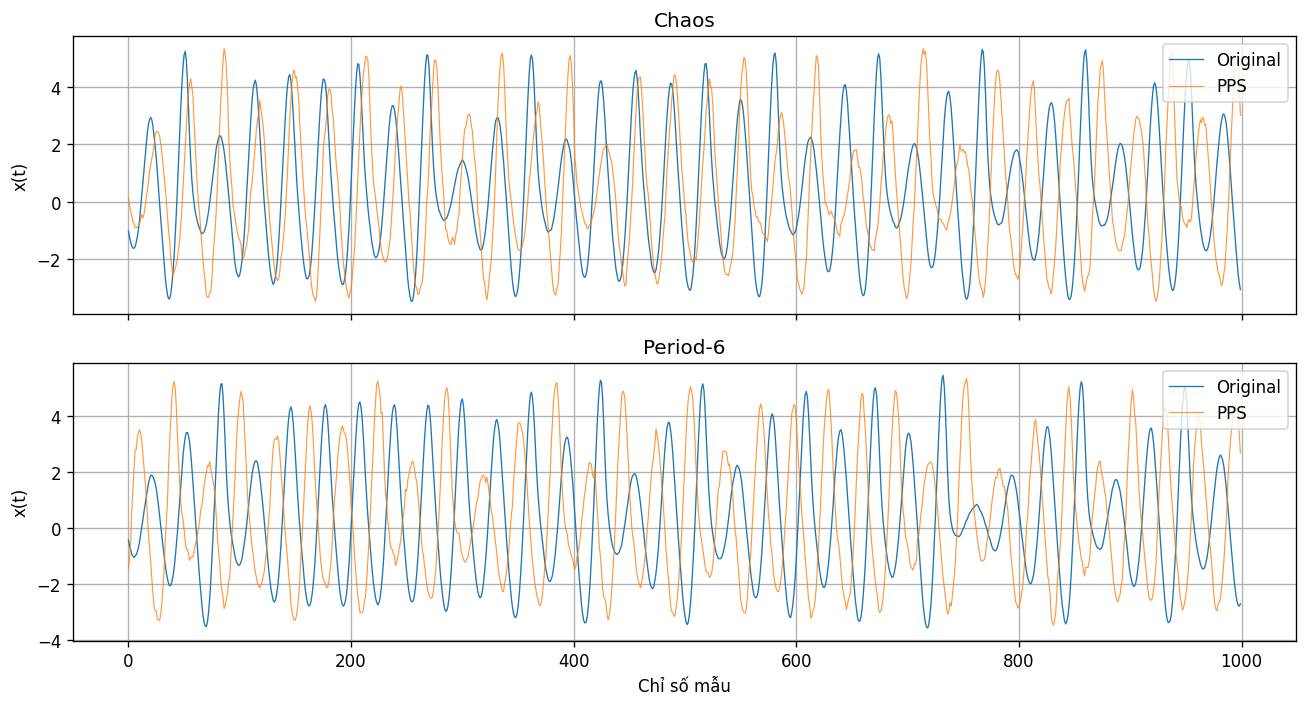

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
display_samples = 1_000

for axis, (name, data) in zip(axes, datasets.items()):
    axis.plot(
        data["signal"][:display_samples],
        linewidth=0.8,
        label="Original",
    )
    axis.plot(
        data["pps"][:display_samples],
        linewidth=0.7,
        alpha=0.8,
        label="PPS",
    )
    axis.set_title(name)
    axis.set_ylabel("x(t)")
    axis.legend(loc="upper right")

axes[-1].set_xlabel("Chỉ số mẫu")
fig.tight_layout()
plt.show()

## Task 7 - Ước lượng correlation dimension theo scale

Correlation sum loại cặp gần nhau theo thời gian bằng Theiler window. Đạo hàm cục bộ của `log(C)` theo `log(epsilon)` được ước lượng bằng hồi quy trên năm scale lân cận.

In [10]:
LOG_EPSILON = np.linspace(-3.5, -0.5, 31)
THEILER_WINDOW = 80
DIMENSION_MAX_POINTS = 2_500
MIN_PAIR_COUNT = 20


def local_slopes(x, y, half_window=2):
    """Estimate local slopes with short regressions."""
    slopes = np.full(len(x), np.nan)
    for index in range(len(x)):
        start = max(0, index - half_window)
        stop = min(len(x), index + half_window + 1)
        valid = np.isfinite(y[start:stop])
        if valid.sum() >= 3:
            slopes[index] = np.polyfit(
                x[start:stop][valid],
                y[start:stop][valid],
                1,
            )[0]
    return slopes


def correlation_dimension_curve(
    signal,
    log_epsilon=LOG_EPSILON,
    theiler_window=THEILER_WINDOW,
    max_points=DIMENSION_MAX_POINTS,
):
    """Estimate correlation dimension across scales."""
    embedded = backward_embedding(signal)[:max_points]
    n_points = len(embedded)
    epsilon = np.exp(log_epsilon)
    pairs = cKDTree(embedded).query_pairs(
        epsilon.max(), output_type="ndarray"
    )
    if len(pairs) == 0:
        return np.full(len(log_epsilon), np.nan)

    temporal_gap = pairs[:, 1] - pairs[:, 0]
    pairs = pairs[temporal_gap > theiler_window]
    distances = np.linalg.norm(
        embedded[pairs[:, 0]] - embedded[pairs[:, 1]], axis=1
    )
    distances.sort()
    pair_counts = np.searchsorted(distances, epsilon, side="right")
    eligible_pairs = (
        (n_points - theiler_window - 1)
        * (n_points - theiler_window)
        / 2
    )
    correlation_sum = pair_counts / eligible_pairs
    log_correlation = np.full(len(epsilon), np.nan)
    valid = pair_counts >= MIN_PAIR_COUNT
    log_correlation[valid] = np.log(correlation_sum[valid])
    return local_slopes(log_epsilon, log_correlation)

## Task 8 - Sinh 30 PPS và thực hiện surrogate test

Thống kê kiểm định là trung bình `d_c` trong dải -2.5 đến -1.5. Rank test một phía dùng đối thuyết `d_c(original) < d_c(PPS)`; với 30 surrogate, p-value nhỏ nhất là 1/31.

In [11]:
def generate_pps_ensemble(signal, rho, size, seed):
    """Generate an independently seeded PPS ensemble."""
    seeds = np.random.SeedSequence(seed).spawn(size)
    return [
        generate_pps_signal(
            signal=signal,
            tau=DELAY,
            m=EMBEDDING_DIMENSION,
            rho=rho,
            rng=np.random.default_rng(child_seed),
        )
        for child_seed in seeds
    ]


dimension_results = {}
for dataset_index, (name, data) in enumerate(datasets.items()):
    ensemble = generate_pps_ensemble(
        signal=data["signal"],
        rho=optimal_rho[name],
        size=N_SURROGATES,
        seed=50_000 + dataset_index,
    )
    surrogate_curves = np.vstack(
        [
            correlation_dimension_curve(surrogate)
            for surrogate in ensemble
        ]
    )
    dimension_results[name] = {
        "original": correlation_dimension_curve(data["signal"]),
        "surrogates": surrogate_curves,
    }

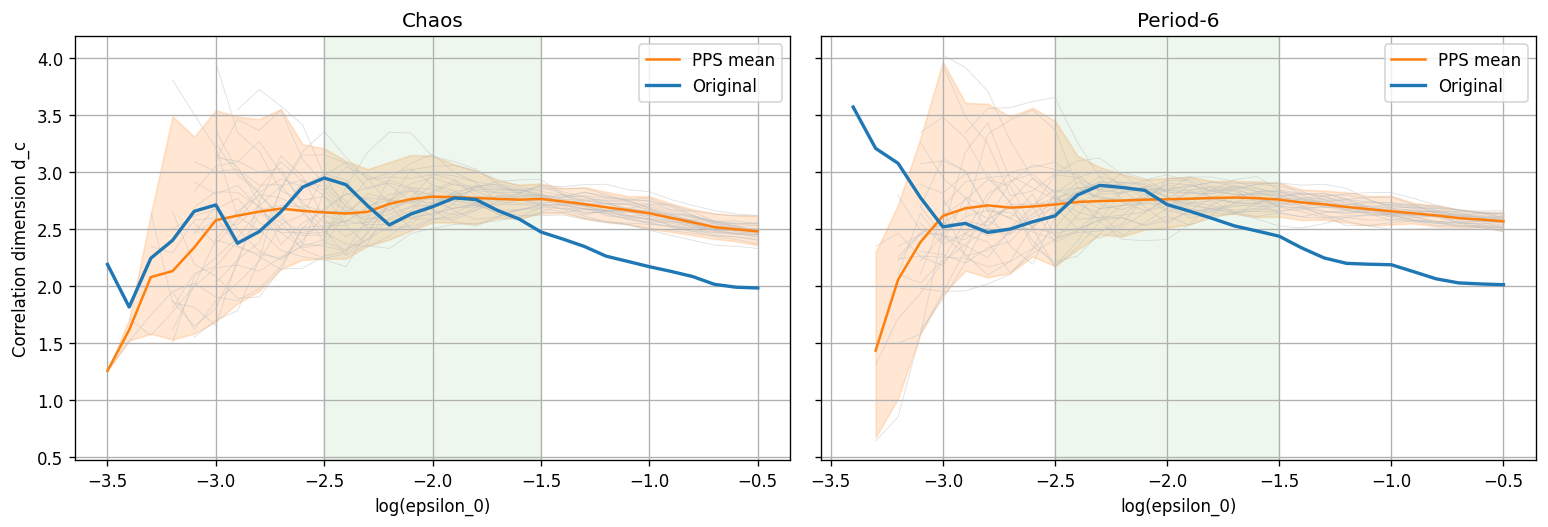

,original_statistic,surrogate_mean,p_value,decision
dataset,,,,
Chaos,2.698642,2.733040,0.387097,Fail to reject H0
Period-6,2.676212,2.757802,0.258065,Fail to reject H0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
test_rows = []
test_band = (LOG_EPSILON >= -2.5) & (LOG_EPSILON <= -1.5)

for axis, (name, result) in zip(axes, dimension_results.items()):
    original_curve = result["original"]
    surrogate_curves = result["surrogates"]
    finite_counts = np.sum(np.isfinite(surrogate_curves), axis=0)
    surrogate_mean = np.divide(
        np.nansum(surrogate_curves, axis=0),
        finite_counts,
        out=np.full(surrogate_curves.shape[1], np.nan),
        where=finite_counts > 0,
    )
    lower = np.full(surrogate_curves.shape[1], np.nan)
    upper = np.full(surrogate_curves.shape[1], np.nan)
    for scale_index in np.flatnonzero(finite_counts):
        scale_values = surrogate_curves[:, scale_index]
        scale_values = scale_values[np.isfinite(scale_values)]
        lower[scale_index], upper[scale_index] = np.percentile(
            scale_values, (2.5, 97.5)
        )

    for curve in surrogate_curves:
        axis.plot(
            LOG_EPSILON,
            curve,
            color="0.75",
            linewidth=0.5,
            alpha=0.5,
        )
    axis.fill_between(
        LOG_EPSILON,
        lower,
        upper,
        color="tab:orange",
        alpha=0.18,
    )
    axis.plot(
        LOG_EPSILON,
        surrogate_mean,
        color="tab:orange",
        label="PPS mean",
    )
    axis.plot(
        LOG_EPSILON,
        original_curve,
        color="tab:blue",
        linewidth=2,
        label="Original",
    )
    axis.axvspan(-2.5, -1.5, color="tab:green", alpha=0.08)
    axis.set_title(name)
    axis.set_xlabel("log(epsilon_0)")
    axis.legend()

    original_statistic = np.nanmean(original_curve[test_band])
    surrogate_statistics = np.nanmean(
        surrogate_curves[:, test_band], axis=1
    )
    p_value = (
        1 + np.count_nonzero(
            surrogate_statistics <= original_statistic
        )
    ) / (N_SURROGATES + 1)
    test_rows.append(
        {
            "dataset": name,
            "original_statistic": original_statistic,
            "surrogate_mean": surrogate_statistics.mean(),
            "p_value": p_value,
            "decision": (
                "Reject H0"
                if p_value <= ALPHA
                else "Fail to reject H0"
            ),
        }
    )

axes[0].set_ylabel("Correlation dimension d_c")
fig.tight_layout()
plt.show()

hypothesis_results = pd.DataFrame(test_rows).set_index("dataset")
hypothesis_results

## Task 9 - Tổng hợp tiêu chí validation

Bảng cuối đối chiếu trực tiếp kết quả với ba nhóm tiêu chí. Ngưỡng lỗi hình học 0.05 là ngưỡng thực dụng trên đường chéo attractor, không phải ngưỡng từ bài báo.

In [13]:
validation_rows = []
expected_decisions = {
    "Chaos": "Reject H0",
    "Period-6": "Fail to reject H0",
}

for name in datasets:
    best_index = int(np.argmax(rho_results[name]["mean"][0]))
    has_interior_peak = 0 < best_index < len(RHO_CANDIDATES) - 1
    c2_curve = rho_results[name]["mean"][0]
    rho_shape_pass = bool(
        has_interior_peak
        and c2_curve[best_index] > c2_curve[0]
        and c2_curve[best_index] > c2_curve[-1]
    )
    rho_scale_pass = bool(
        0.002 <= optimal_rho[name] <= 0.006
    )
    geometry_pass = geometry_errors[name] < 0.05
    null_pass = (
        hypothesis_results.loc[name, "decision"]
        == expected_decisions[name]
    )
    validation_rows.append(
        {
            "dataset": name,
            "rho_shape_pass": rho_shape_pass,
            "rho_scale_pass": rho_scale_pass,
            "geometry_pass": geometry_pass,
            "null_test_pass": null_pass,
            "overall_pass": (
                rho_shape_pass
                and rho_scale_pass
                and geometry_pass
                and null_pass
            ),
        }
    )

validation_summary = pd.DataFrame(validation_rows).set_index("dataset")
validation_summary

,rho_shape_pass,rho_scale_pass,geometry_pass,null_test_pass,overall_pass
dataset,,,,,
Chaos,True,False,True,False,False
Period-6,True,False,True,True,False


### Cách đọc kết quả

- `rho_shape_pass`: C2 có peak nội tại, cao hơn hai biên của grid.
- `rho_scale_pass`: r* thuộc vùng tham chiếu 0.002–0.006.
- `geometry_pass`: PPS không lệch xa attractor gốc theo kiểm tra chuẩn hóa.
- `null_test_pass`: chaos bị bác bỏ H0, còn period-6 không bị bác bỏ.
- Chỉ chuyển sang kiểm chứng PPG khi cả hai dòng đều đạt `overall_pass`.

## Báo cáo kết quả và đánh giá PPS core

### Thay đổi đã kiểm chứng

- `count_matching_segments` đã được sửa để đếm maximal consecutive runs có độ dài đúng bằng `segment_length`; các cửa sổ chồng lấn trong một run dài không còn được tính riêng.
- Cả 6 nhóm test thủ công đều PASS, bao gồm giới hạn một run dài 10 điểm cho `C2...C9 = 0` và `C10 = 1`.
- `optimize_rho` và diagnostic sweep cùng gọi một hàm `count_matching_segments`, nên tiêu chí tối ưu và tiêu chí vẽ đồ thị đã đồng nhất. Transition kernel, self-match, temporal neighbors và scalar reconstruction không bị thay đổi.

### Kết quả chạy lại

- **Rho shape:** cả hai đường `C2(r)` đã thoát khỏi biên dưới. `C2` bằng 0 tại `r` nhỏ nhất, tăng lên peak nội tại rồi giảm còn khoảng 18–21 tại `r = 1`. Tiêu chí hình dạng peak PASS cho cả chaos và period-6.
- **Rho scale:** cả hai dataset cho `r* = 0.1`, lớn hơn đáng kể so với vùng tham chiếu 0.002–0.006. Tiêu chí scale vẫn FAIL.
- **Geometry:** PPS giữ được độ phân tán và coarse attractor geometry. Sai số hình học chuẩn hóa là 0.0104 cho chaos và 0.0107 cho period-6, đều nhỏ hơn ngưỡng thực dụng 0.05.
- **Null test:** period-6 cho kết quả đúng kỳ vọng `Fail to reject H0` với `p = 0.258`. Chaos vẫn `Fail to reject H0` với `p = 0.387`, nên chưa đạt yêu cầu phân biệt null.
- Vì `rho_scale_pass` và chaos `null_test_pass` còn false, cả hai dataset vẫn chưa đạt `overall_pass`; chưa chuyển core sang dữ liệu PPG.

### Đánh giá kết quả

Việc sửa định nghĩa `C_n` đã giải quyết đúng bottleneck chính: peak không còn collapse về `r -> 0` và xuất hiện rõ ở vùng trung gian của grid. Do đó không có lý do thay đổi transition rule ở vòng này. Tuy nhiên, vị trí peak tại 0.1 cho thấy thang khoảng cách của thực nghiệm hiện chưa tương thích với thang `r` tham chiếu. Surrogate tại `r = 0.1` bảo toàn hình học nhưng chưa phá vỡ fine organization của chaos theo cách đủ mạnh để correlation-dimension rank test bác bỏ H0.

### Phần cần validate tiếp theo

1. **Distance scale và normalization:** xác nhận paper dùng tín hiệu thô, chuẩn hóa từng tọa độ, z-score hay scale theo attractor diameter trước khi áp dụng `rho`. Đây là ưu tiên cao nhất vì shape đã đúng nhưng peak lệch scale.
2. **Mô phỏng Rössler:** đối chiếu integrator, cách đưa dynamical noise, thời gian transient và sampling convention với thiết lập tham chiếu; các yếu tố này trực tiếp thay đổi khoảng cách trong không gian pha.
3. **Độ ổn định của `r*`:** tăng số trial, chạy nhiều seed và dùng grid mịn quanh 0.1 để xác nhận peak không phải dao động Monte Carlo.
4. **Correlation dimension:** kiểm tra scaling region, Theiler window và độ ổn định của thống kê trước khi kết luận lỗi nằm ở PPS generator.
5. **Candidate semantics:** tiếp tục giữ nguyên self-match và temporal neighbors. Chỉ xem xét lại candidate set nếu đã đồng bộ scale và mô phỏng nhưng chaos vẫn không bị bác bỏ.

**Kết luận của lần sửa này:** Có, sau khi sửa định nghĩa `C_n`, các đường `C_n(r)` đã xuất hiện peak rõ ở vùng `r` trung gian thay vì collapse về `r -> 0`. Core đã qua bước sửa bottleneck về hình dạng rho-sweep, nhưng chưa validated hoàn toàn do sai scale và chưa phân biệt được chaos.